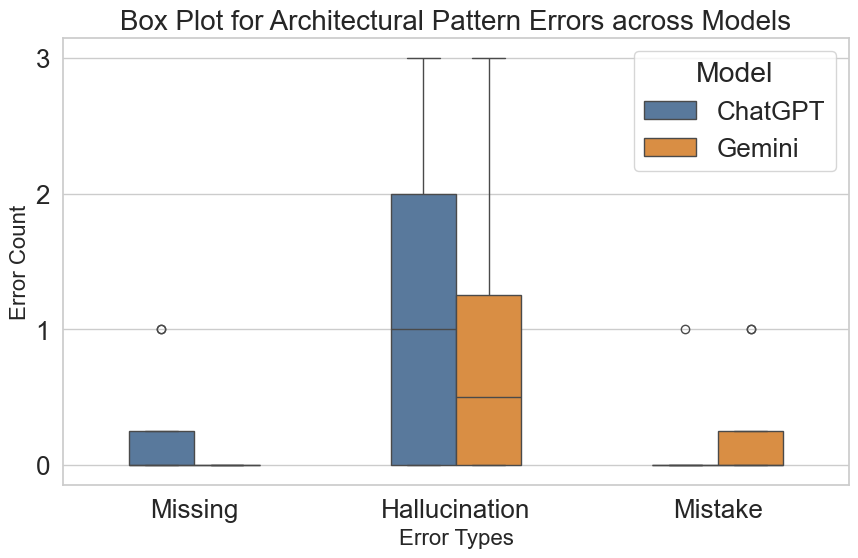

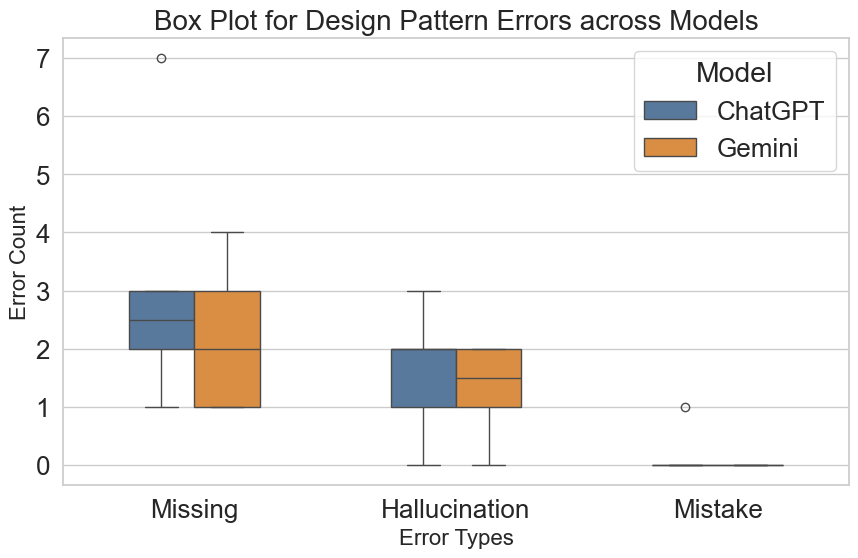

In [5]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

# Load the Excel file
file_path = 'Task_2_Summary.xlsx'
excel_data = pd.ExcelFile(file_path)

# Load sheets
chatgpt_df = excel_data.parse('ChatGPT', header=1)
gemini_df  = excel_data.parse('Gemini', header=1)
# claude_df  = excel_data.parse('Claude', header=1)
# mistral_df = excel_data.parse('Mistral', header=1)

# Rename columns for consistency
cols = [
    'Code',
    'Missing_Architectural', 'Hallucination_Architectural', 'Mistake_Architectural',
    'Missing_Design', 'Hallucination_Design', 'Mistake_Design'
]
chatgpt_df.columns = cols
gemini_df.columns  = cols
# claude_df.columns  = cols
# mistral_df.columns = cols

# Add model identifiers
chatgpt_df['Model'] = 'ChatGPT'
gemini_df['Model']  = 'Gemini'
# claude_df['Model']  = 'Claude'
# mistral_df['Model'] = 'Mistral'

# Combine all data
combined_df = pd.concat([chatgpt_df, gemini_df], ignore_index=True)
# combined_df = pd.concat([chatgpt_df, gemini_df, claude_df, mistral_df], ignore_index=True)

# Define columns
architectural_columns = ['Missing_Architectural', 'Hallucination_Architectural', 'Mistake_Architectural']
design_columns        = ['Missing_Design', 'Hallucination_Design', 'Mistake_Design']

# Melt data for plotting
melted_arch_df = combined_df.melt(
    id_vars=['Model'],
    value_vars=architectural_columns,
    var_name='Error Type',
    value_name='Values'
)

melted_design_df = combined_df.melt(
    id_vars=['Model'],
    value_vars=design_columns,
    var_name='Error Type',
    value_name='Values'
)

# Map labels to show only Missing / Hallucination / Mistake on x-axis
arch_labels_map = {
    'Missing_Architectural': 'Missing',
    'Hallucination_Architectural': 'Hallucination',
    'Mistake_Architectural': 'Mistake'
}
design_labels_map = {
    'Missing_Design': 'Missing',
    'Hallucination_Design': 'Hallucination',
    'Mistake_Design': 'Mistake'
}

melted_arch_df['Error Type']   = melted_arch_df['Error Type'].map(arch_labels_map)
melted_design_df['Error Type'] = melted_design_df['Error Type'].map(design_labels_map)

# Custom colors for each model
custom_palette = {
    'ChatGPT': '#4E79A7',
    'Gemini':  '#F28E2B',
    # 'Claude':  '#E15759',
    # 'Mistral': '#76B7B2'
}

# Increase font size (global)
sns.set_theme(style="whitegrid", font_scale=1.7)

# Output PDF names
pdf_arch_out   = "boxplot_task2_architectural_patterns.pdf"
pdf_design_out = "boxplot_task2_design_patterns.pdf"

# -------------------------
# 1) ARCHITECTURAL patterns plot (PDF)
# -------------------------
plt.figure(figsize=(9, 6))
ax1 = sns.boxplot(
    data=melted_arch_df,
    x='Error Type',
    y='Values',
    hue='Model',
    palette=custom_palette,
    width=0.5,
    dodge=True
)
ax1.set_title('Box Plot for Architectural Pattern Errors across Models', fontsize=20)
ax1.set_xlabel('Error Types', fontsize=16)
ax1.set_ylabel('Error Count', fontsize=16)

# Only integer ticks on y-axis
ax1.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(pdf_arch_out, format='pdf')
plt.show()

# -------------------------
# 2) DESIGN patterns plot (PDF)
# -------------------------
plt.figure(figsize=(9, 6))
ax2 = sns.boxplot(
    data=melted_design_df,
    x='Error Type',
    y='Values',
    hue='Model',
    palette=custom_palette,
    width=0.5,
    dodge=True
)
ax2.set_title('Box Plot for Design Pattern Errors across Models', fontsize=20)
ax2.set_xlabel('Error Types', fontsize=16)
ax2.set_ylabel('Error Count', fontsize=16)

# Only integer ticks on y-axis
ax2.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(pdf_design_out, format='pdf')
plt.show()


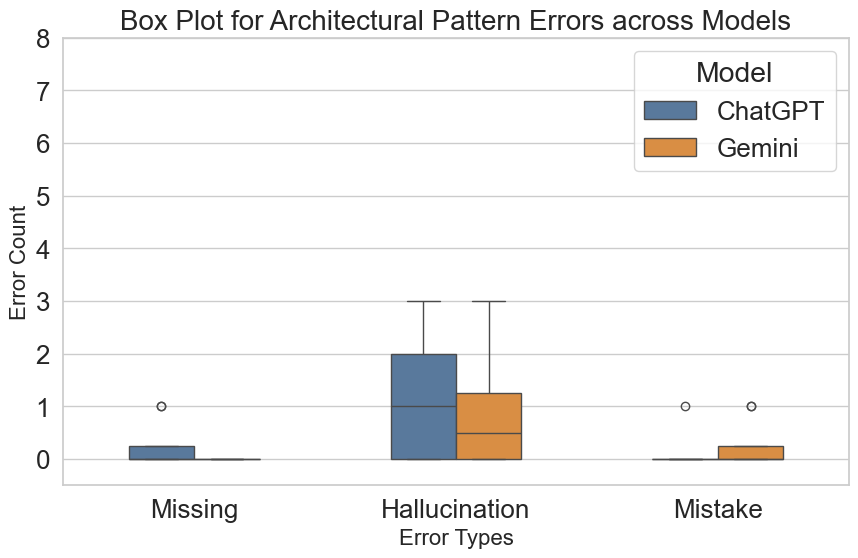

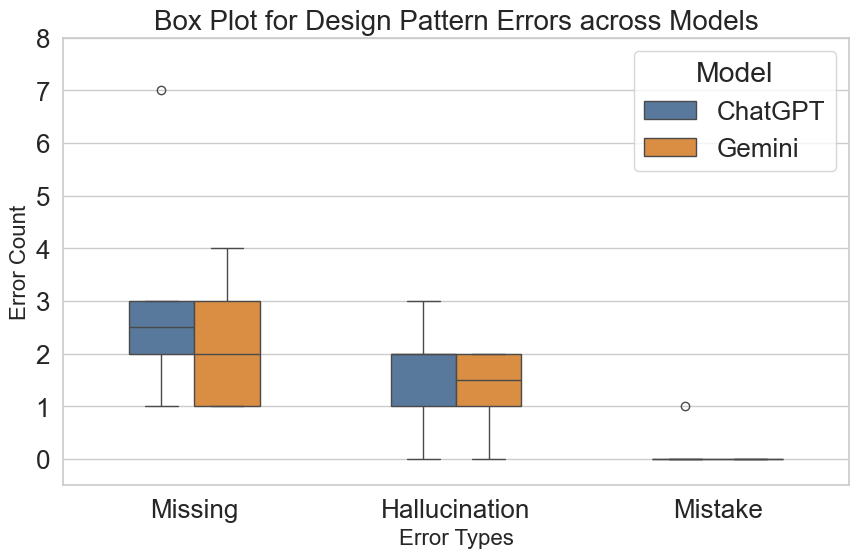

In [6]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
import numpy as np

# Load the Excel file
file_path = 'Task_2_Summary.xlsx'
excel_data = pd.ExcelFile(file_path)

# Load sheets
chatgpt_df = excel_data.parse('ChatGPT', header=1)
gemini_df  = excel_data.parse('Gemini', header=1)
# claude_df  = excel_data.parse('Claude', header=1)
# mistral_df = excel_data.parse('Mistral', header=1)

# Rename columns for consistency
cols = [
    'Code',
    'Missing_Architectural', 'Hallucination_Architectural', 'Mistake_Architectural',
    'Missing_Design', 'Hallucination_Design', 'Mistake_Design'
]
chatgpt_df.columns = cols
gemini_df.columns  = cols
# claude_df.columns  = cols
# mistral_df.columns = cols

# Add model identifiers
chatgpt_df['Model'] = 'ChatGPT'
gemini_df['Model']  = 'Gemini'
# claude_df['Model']  = 'Claude'
# mistral_df['Model'] = 'Mistral'

# Combine all data
combined_df = pd.concat([chatgpt_df, gemini_df], ignore_index=True)
# combined_df = pd.concat([chatgpt_df, gemini_df, claude_df, mistral_df], ignore_index=True)

# Define columns
architectural_columns = ['Missing_Architectural', 'Hallucination_Architectural', 'Mistake_Architectural']
design_columns        = ['Missing_Design', 'Hallucination_Design', 'Mistake_Design']

# Melt data for plotting
melted_arch_df = combined_df.melt(
    id_vars=['Model'],
    value_vars=architectural_columns,
    var_name='Error Type',
    value_name='Values'
)

melted_design_df = combined_df.melt(
    id_vars=['Model'],
    value_vars=design_columns,
    var_name='Error Type',
    value_name='Values'
)

# Map labels to show only Missing / Hallucination / Mistake on x-axis
arch_labels_map = {
    'Missing_Architectural': 'Missing',
    'Hallucination_Architectural': 'Hallucination',
    'Mistake_Architectural': 'Mistake'
}
design_labels_map = {
    'Missing_Design': 'Missing',
    'Hallucination_Design': 'Hallucination',
    'Mistake_Design': 'Mistake'
}

melted_arch_df['Error Type']   = melted_arch_df['Error Type'].map(arch_labels_map)
melted_design_df['Error Type'] = melted_design_df['Error Type'].map(design_labels_map)

# Custom colors for each model
custom_palette = {
    'ChatGPT': '#4E79A7',
    'Gemini':  '#F28E2B',
    # 'Claude':  '#E15759',
    # 'Mistral': '#76B7B2'
}

# Increase font size (global)
sns.set_theme(style="whitegrid", font_scale=1.7)

# -------------------------
# SAME Y SCALE FOR BOTH PLOTS
# -------------------------
global_max = np.nanmax([
    melted_arch_df['Values'].max(),
    melted_design_df['Values'].max()
])

# Integer upper bound + small margin
y_max = int(np.ceil(global_max)) + 1

# Padding below zero
y_min = -0.5

# Output PDF names
pdf_arch_out   = "boxplot_task2_architectural_patterns_same_size.pdf"
pdf_design_out = "boxplot_task2_design_patterns_same_size.pdf"

# -------------------------
# 1) ARCHITECTURAL patterns plot (PDF)
# -------------------------
plt.figure(figsize=(9, 6))
ax1 = sns.boxplot(
    data=melted_arch_df,
    x='Error Type',
    y='Values',
    hue='Model',
    palette=custom_palette,
    width=0.5,
    dodge=True
)
ax1.set_title('Box Plot for Architectural Pattern Errors across Models', fontsize=20)
ax1.set_xlabel('Error Types', fontsize=16)
ax1.set_ylabel('Error Count', fontsize=16)

# Same Y scale
ax1.set_ylim(y_min, y_max)

# Only integer ticks on y-axis
ax1.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(pdf_arch_out, format='pdf')
plt.show()

# -------------------------
# 2) DESIGN patterns plot (PDF)
# -------------------------
plt.figure(figsize=(9, 6))
ax2 = sns.boxplot(
    data=melted_design_df,
    x='Error Type',
    y='Values',
    hue='Model',
    palette=custom_palette,
    width=0.5,
    dodge=True
)
ax2.set_title('Box Plot for Design Pattern Errors across Models', fontsize=20)
ax2.set_xlabel('Error Types', fontsize=16)
ax2.set_ylabel('Error Count', fontsize=16)

# Same Y scale
ax2.set_ylim(y_min, y_max)

# Only integer ticks on y-axis
ax2.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(pdf_design_out, format='pdf')
plt.show()


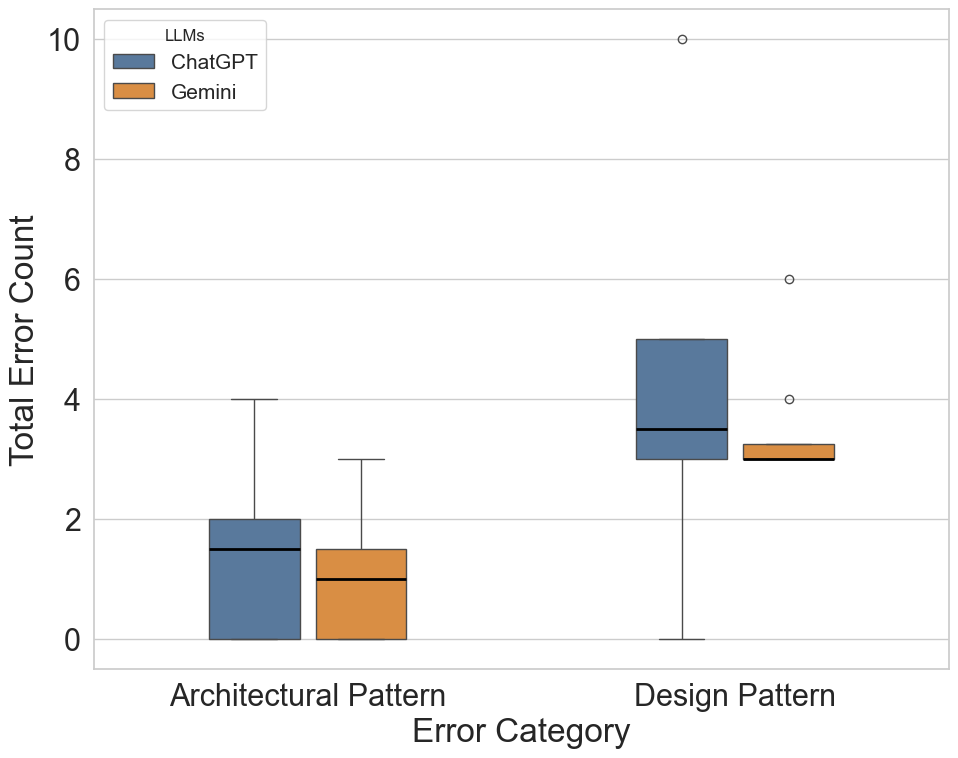

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Excel file
file_path = 'Task_2_Macro.xlsx'
excel_data = pd.ExcelFile(file_path)

# Prepare a combined DataFrame for plotting
combined_data = pd.DataFrame()

# Loop through each sheet and add the data to the combined DataFrame
for sheet in ['ChatGPT', 'Gemini']:
    df = excel_data.parse(sheet)
    # Adding a column to indicate the sheet name (source) for each row
    df['Source'] = sheet
    combined_data = pd.concat([combined_data, df[['Architectural Pattern', 'Design Pattern', 'Source']]])

# Melt the combined data for easier box plotting
melted_data = pd.melt(
    combined_data,
    id_vars='Source',
    value_vars=['Architectural Pattern', 'Design Pattern'],
    var_name='Metric',
    value_name='Value'
)

# Define custom color mapping for each source
color_palette = {
    'ChatGPT': '#4E79A7',
    'Gemini': '#F28E2B'
    # 'Claude': '#E15759',
    # 'Mistral': '#76B7B2'
}

# Plotting with custom colors
plt.figure(figsize=(10, 8))
sns.boxplot(
    data=melted_data,
    x='Metric',
    y='Value',
    hue='Source',
    gap=0.15,
    width=0.5,
    dodge=True,
    palette=color_palette,
    medianprops={"color": "black", "linewidth": 2}
)

plt.ylabel("Total Error Count", fontsize=24)
plt.xlabel("Error Category", fontsize=24)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.legend(title="LLMs", fontsize=15, title_fontsize=12, loc='upper left')

plt.tight_layout()

# Save as PDF instead of PNG
output_file_path = 'macro_ARCH_DESIGN_box_plots_combined.pdf'
plt.savefig(output_file_path, format='pdf')

# Show plot
plt.show()
